In [1]:
import numpy as np
import matplotlib.pyplot as plt

In [2]:
n = 100
x = np.linspace(0, 1, n)
sigma = 0.1

In [3]:
u0 = np.exp(-(x - 0.5)**2 / (2 * sigma**2))
v0 = np.sin(np.pi * x)

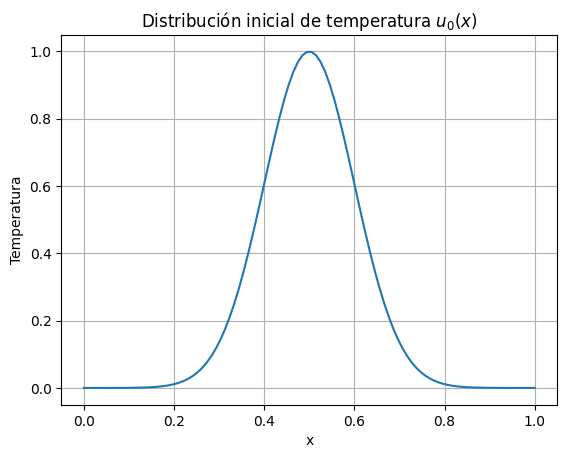

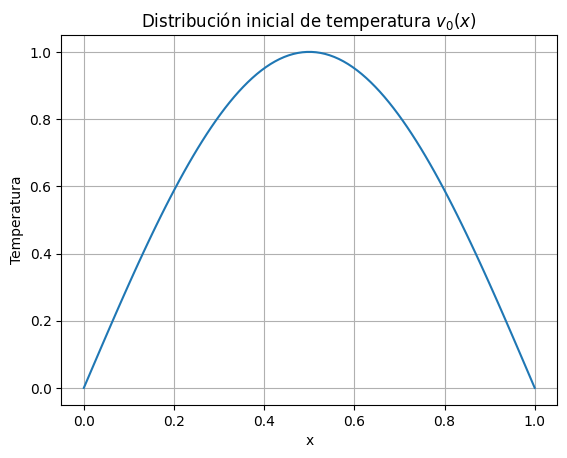

In [4]:
plt.plot(x, u0)
plt.title("Distribución inicial de temperatura $u_0(x)$")
plt.xlabel("x")
plt.ylabel("Temperatura")
plt.grid(True)
plt.show()

plt.plot(x, v0)
plt.title("Distribución inicial de temperatura $v_0(x)$")
plt.xlabel("x")
plt.ylabel("Temperatura")
plt.grid(True)
plt.show()


In [5]:
dx = 1 / (n - 1)
dt = 1e-4                  # paso de tiempo
T = 0.05                   # tiempo 
nt = int(T / dt)           # número de pasos de tiempo
alpha = 1                  # difusividad térmica, en 1

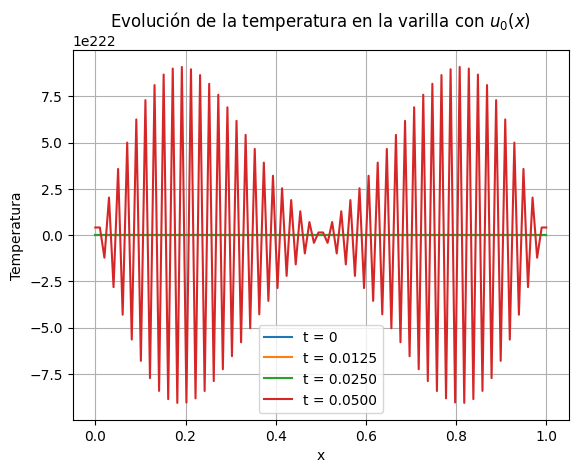

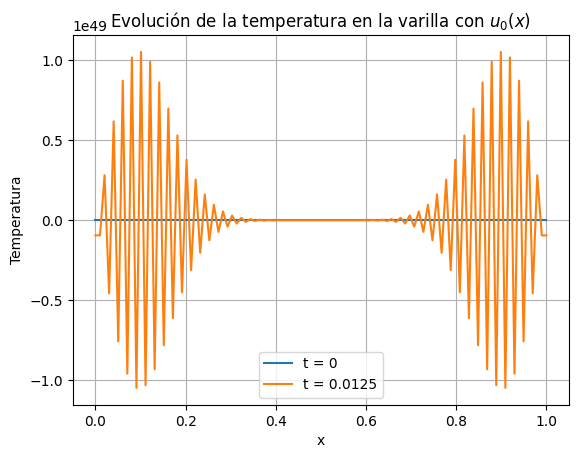

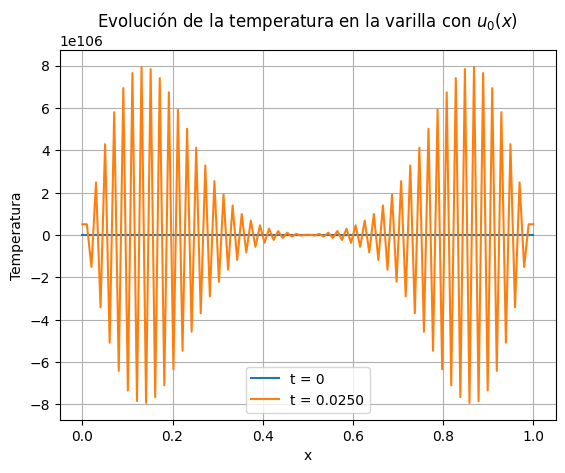

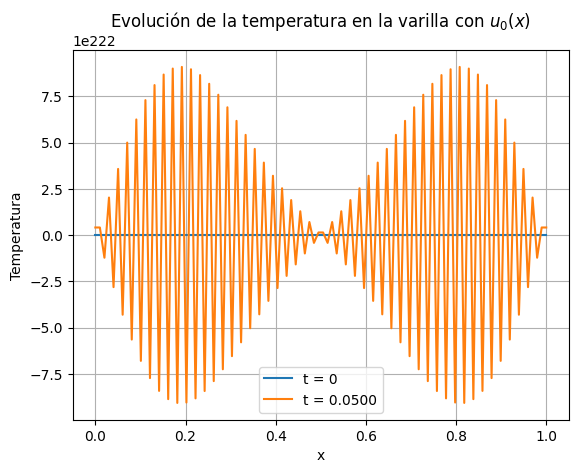

In [6]:
# frontera de Neumann
def neumann(u):
    u[0] = u[1]
    u[-1] = u[-2]
    return u

u_h = [u0.copy()]

for _ in range(nt):
    u_n = u0.copy()
    for j in range(1, n - 1):
        u_n[j] = u0[j] + alpha * dt / dx**2 * (u0[j-1] - 2*u0[j] + u0[j+1])
    u0 = neumann(u_n)
    u_h.append(u0.copy())


# gráfica u0
plt.plot(x, u_h[0], label='t = 0')
plt.plot(x, u_h[nt//4], label=f't = {T/4:.4f}')
plt.plot(x, u_h[nt//2], label=f't = {T/2:.4f}')
plt.plot(x, u_h[-1], label=f't = {T:.4f}')
plt.title("Evolución de la temperatura en la varilla con $u_0(x)$")
plt.xlabel("x")
plt.ylabel("Temperatura")
plt.legend()
plt.grid(True)
plt.show()

plt.plot(x, u_h[0], label='t = 0')
plt.plot(x, u_h[nt//4], label=f't = {T/4:.4f}')
plt.title("Evolución de la temperatura en la varilla con $u_0(x)$ ")
plt.xlabel("x")
plt.ylabel("Temperatura")
plt.legend()
plt.grid(True)
plt.show()

plt.plot(x, u_h[0], label='t = 0')
plt.plot(x, u_h[nt//2], label=f't = {T/2:.4f}')
plt.title("Evolución de la temperatura en la varilla con $u_0(x)$")
plt.xlabel("x")
plt.ylabel("Temperatura")
plt.legend()
plt.grid(True)
plt.show()

plt.plot(x, u_h[0], label='t = 0')
plt.plot(x, u_h[-1], label=f't = {T:.4f}')
plt.title("Evolución de la temperatura en la varilla con $u_0(x)$")
plt.xlabel("x")
plt.ylabel("Temperatura")
plt.legend()
plt.grid(True)
plt.show()



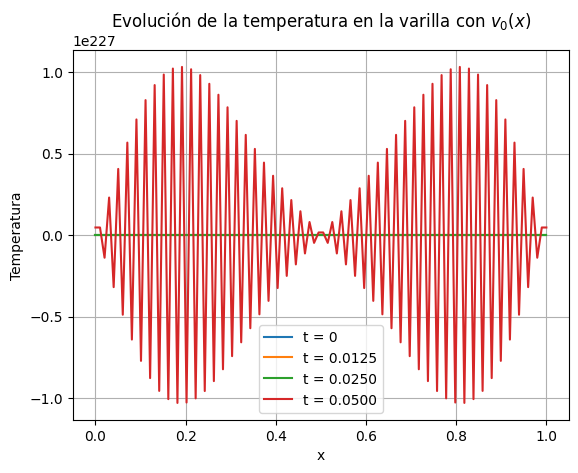

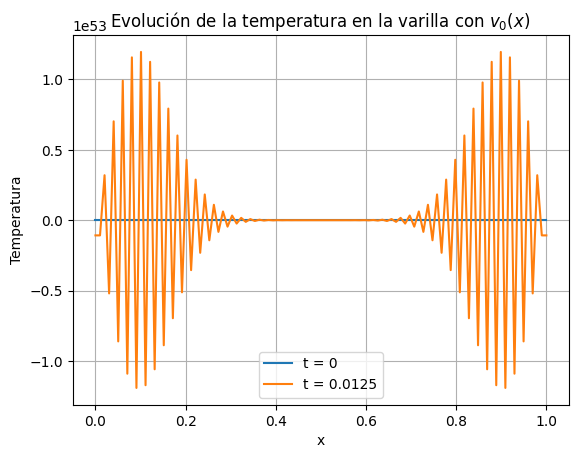

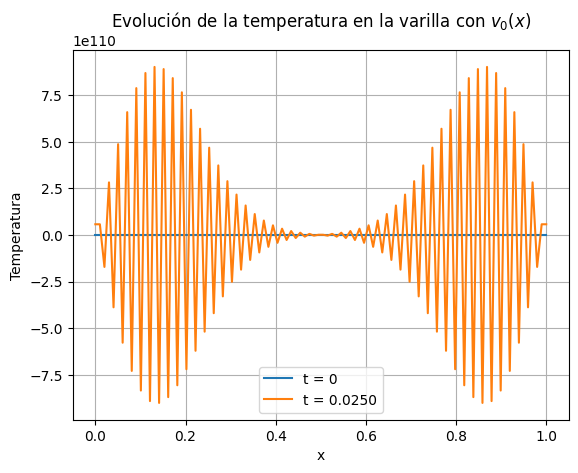

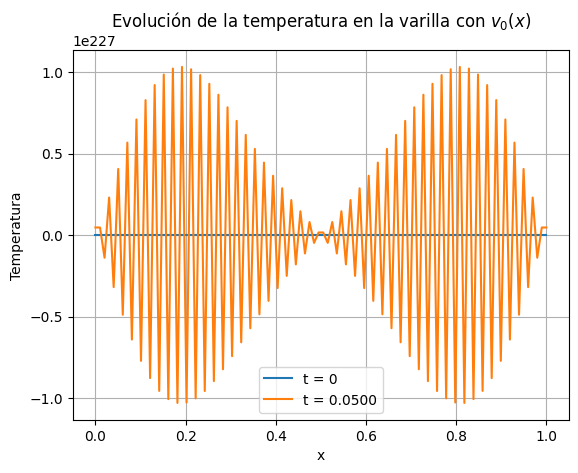

In [7]:
v_h = [v0.copy()]

for _ in range(nt):
    v_n = v0.copy()
    for j in range(1, n - 1):
        v_n[j] = v0[j] + alpha * dt / dx**2 * (v0[j-1] - 2*v0[j] + v0[j+1])
    v0 = neumann(v_n)
    v_h.append(v0.copy())

# gráfica v0
plt.plot(x, v_h[0], label='t = 0')
plt.plot(x, v_h[nt//4], label=f't = {T/4:.4f}')
plt.plot(x, v_h[nt//2], label=f't = {T/2:.4f}')
plt.plot(x, v_h[-1], label=f't = {T:.4f}')
plt.title("Evolución de la temperatura en la varilla con $v_0(x)$")
plt.xlabel("x")
plt.ylabel("Temperatura")
plt.legend()
plt.grid(True)
plt.show()

plt.plot(x, v_h[0], label='t = 0')
plt.plot(x, v_h[nt//4], label=f't = {T/4:.4f}')
plt.title("Evolución de la temperatura en la varilla con $v_0(x)$ ")
plt.xlabel("x")
plt.ylabel("Temperatura")
plt.legend()
plt.grid(True)
plt.show()

plt.plot(x, v_h[0], label='t = 0')
plt.plot(x, v_h[nt//2], label=f't = {T/2:.4f}')
plt.title("Evolución de la temperatura en la varilla con $v_0(x)$")
plt.xlabel("x")
plt.ylabel("Temperatura")
plt.legend()
plt.grid(True)
plt.show()

plt.plot(x, v_h[0], label='t = 0')
plt.plot(x, v_h[-1], label=f't = {T:.4f}')
plt.title("Evolución de la temperatura en la varilla con $v_0(x)$")
plt.xlabel("x")
plt.ylabel("Temperatura")
plt.legend()
plt.grid(True)
plt.show()


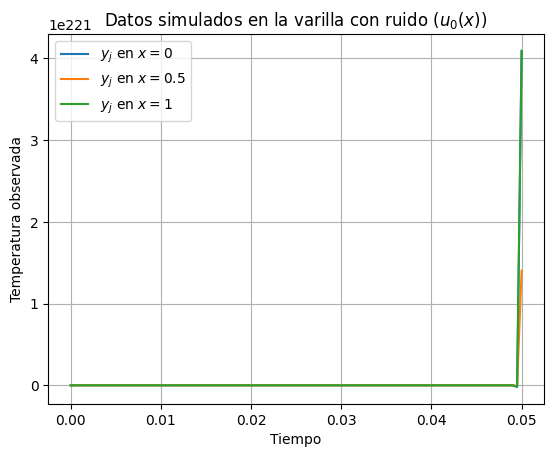

In [ ]:
# generación de datos ruidosos  izquierdo, centro y derecho
sigma_ruido = 0.02
y_izq = []
y_centro = []
y_der = []
t_list = []

salto = int(nt / 100)  

for j, u in enumerate(u_h[::salto]):
    tiempo = j * dt * salto
    t_list.append(tiempo)

    y_izq.append(u[0] + np.random.normal(0, sigma_ruido))        
    y_centro.append(u[n // 2] + np.random.normal(0, sigma_ruido)) 
    y_der.append(u[-1] + np.random.normal(0, sigma_ruido))       

# gráfica
plt.plot(t_list, y_izq, label="$y_j$ en $x = 0$")
plt.plot(t_list, y_centro, label="$y_j$ en $x = 0.5$")
plt.plot(t_list, y_der, label="$y_j$ en $x = 1$")
plt.title("Datos simulados en la varilla con ruido ($u_0(x)$)")
plt.xlabel("Tiempo")
plt.ylabel("Temperatura observada")
plt.legend()
plt.grid(True)
plt.show()


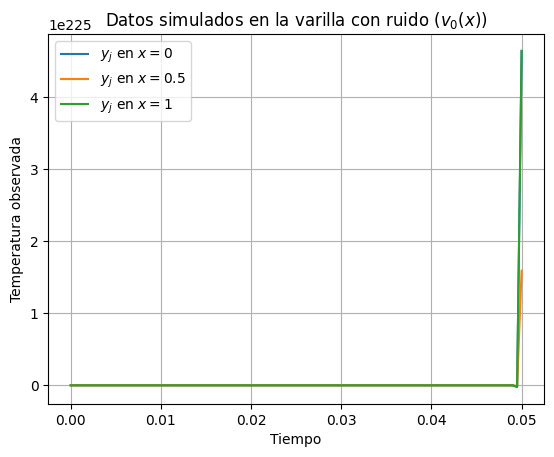

In [22]:
y1_izq = []
y1_centro = []
y1_der = []
t1_list = []

salto = int(nt / 100)  

for j, u in enumerate(v_h[::salto]):
    tiempo = j * dt * salto
    t1_list.append(tiempo)

    y1_izq.append(u[0] + np.random.normal(0, sigma_ruido))        
    y1_centro.append(u[n // 2] + np.random.normal(0, sigma_ruido)) 
    y1_der.append(u[-1] + np.random.normal(0, sigma_ruido))       

# gráfica
plt.plot(t1_list, y1_izq, label="$y_j$ en $x = 0$")
plt.plot(t1_list, y1_centro, label="$y_j$ en $x = 0.5$")
plt.plot(t1_list, y1_der, label="$y_j$ en $x = 1$")
plt.title("Datos simulados en la varilla con ruido ($v_0(x)$)")
plt.xlabel("Tiempo")
plt.ylabel("Temperatura observada")
plt.legend()
plt.grid(True)
plt.show()

In [23]:
import numpy as np

# Definir la matriz A para el esquema de Euler explícito
A = np.eye(n)
for i in range(1, n - 1):
    A[i, i - 1] = alpha * dt / dx**2
    A[i, i]   -= 2 * alpha * dt / dx**2
    A[i, i + 1] = alpha * dt / dx**2

# Condiciones de Neumann en extremos: u[0] = u[1], u[-1] = u[-2]
A[0, 0] = 1 - 2 * alpha * dt / dx**2
A[0, 1] = 2 * alpha * dt / dx**2
A[-1, -1] = 1 - 2 * alpha * dt / dx**2
A[-1, -2] = 2 * alpha * dt / dx**2

# Matriz H (observaciones en posiciones 0, n//2, n-1)
H = np.zeros((3, n))
H[0, 0] = 1       # extremo izquierdo
H[1, n // 2] = 1  # centro
H[2, -1] = 1      # extremo derecho

# Ruido en el modelo y observaciones
Q = 1e-6 * np.eye(n)           # poca incertidumbre en el modelo
R = sigma_ruido**2 * np.eye(3)  # varianza del ruido en observaciones

# Estado inicial y covarianza inicial
u_est = np.zeros(n)
P = np.eye(n)

# Listas para guardar estimaciones
u_estimado = []

# Iteración Kalman
for j in range(len(t_list)):
    # Observación real en este paso
    y = np.array([y_izq[j], y_centro[j], y_der[j]])

    # --- PREDICCIÓN ---
    u_pred = A @ u_est
    P_pred = A @ P @ A.T + Q

    # --- ACTUALIZACIÓN ---
    S = H @ P_pred @ H.T + R
    K = P_pred @ H.T @ np.linalg.inv(S)
    u_est = u_pred + K @ (y - H @ u_pred)
    P = (np.eye(n) - K @ H) @ P_pred

    u_estimado.append(u_est.copy())


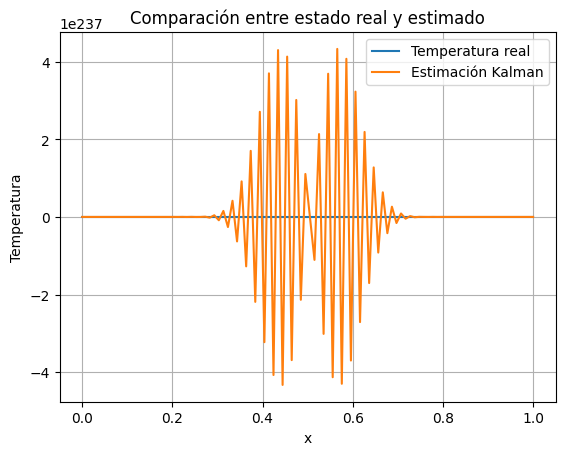

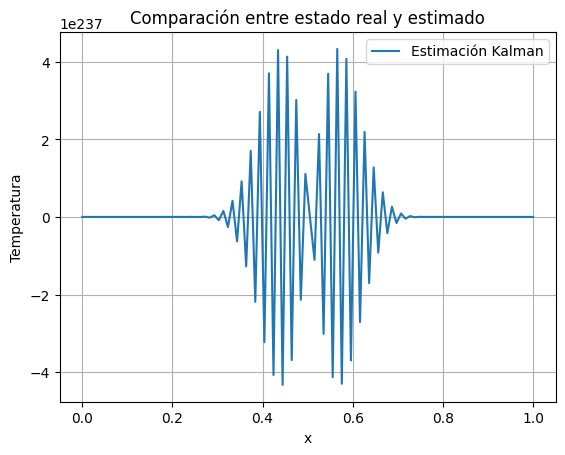

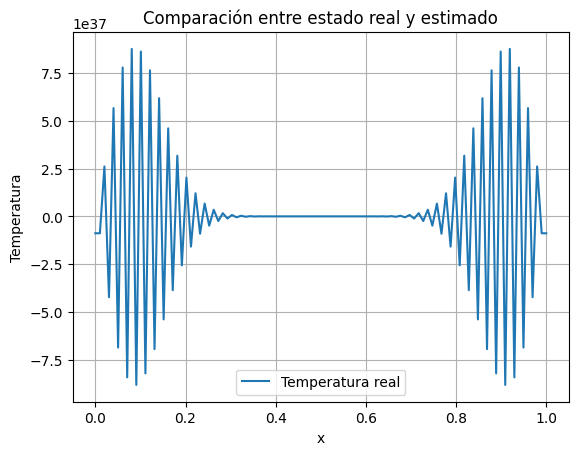

In [26]:
import matplotlib.pyplot as plt

plt.plot(x, u_h[len(t_list)], label="Temperatura real")
plt.plot(x, u_estimado[-1], label="Estimación Kalman")
plt.title("Comparación entre estado real y estimado")
plt.xlabel("x")
plt.ylabel("Temperatura")
plt.legend()
plt.grid(True)
plt.show()

plt.plot(x, u_estimado[-1], label="Estimación Kalman")
plt.title("Comparación entre estado real y estimado")
plt.xlabel("x")
plt.ylabel("Temperatura")
plt.legend()
plt.grid(True)
plt.show()

plt.plot(x, u_h[len(t_list)], label="Temperatura real")
plt.title("Comparación entre estado real y estimado")
plt.xlabel("x")
plt.ylabel("Temperatura")
plt.legend()
plt.grid(True)
plt.show()